# Banking Transaction Data Analytics Project

## Objective
To analyze banking transaction data, identify data quality issues, detect suspicious transactions, and generate business insights.

## Tools Used
- Python
- Pandas
- Matplotlib

## Dataset
Simulated banking transactions dataset with real-world data quality issues.

## Dataset Note
This dataset was synthetically generated and enhanced with realistic data quality issues such as missing values, duplicates, and anomalous transactions to simulate real-world banking data challenges.

## 1. Data Generation

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Set seed for reproducibility
np.random.seed(42)

# Create sample data
n = 100

transaction_ids = range(1001, 1001 + n)
customer_ids = [f"C{str(i).zfill(3)}" for i in np.random.randint(1, 30, n)]

start_date = datetime(2025, 1, 1)
dates = [start_date + timedelta(days=random.randint(0, 30)) for _ in range(n)]

amounts = np.random.randint(50, 15000, n)

transaction_types = np.random.choice(["Deposit", "Withdrawal"], n)

locations = np.random.choice(
    ["Johannesburg", "Pretoria", "Cape Town", "Durban"], n
)

account_types = np.random.choice(
    ["Savings", "Cheque", "Business"], n
)

# Create DataFrame
df = pd.DataFrame({
    "TransactionID": transaction_ids,
    "CustomerID": customer_ids,
    "Date": dates,
    "Amount": amounts,
    "TransactionType": transaction_types,
    "Location": locations,
    "AccountType": account_types
})

# Save dataset
df.to_csv("banking_transactions.csv", index=False)

df.head()

,TransactionID,CustomerID,Date,Amount,TransactionType,Location,AccountType
0,1001,C007,2025-01-18,12793,Withdrawal,Cape Town,Cheque
1,1002,C020,2025-01-12,7679,Deposit,Pretoria,Cheque
2,1003,C029,2025-01-14,12040,Deposit,Durban,Cheque
3,1004,C015,2025-01-18,9517,Deposit,Johannesburg,Cheque
4,1005,C011,2025-01-04,1066,Withdrawal,Durban,Business


## 2. Simulating Real-World Data Issues

In [3]:
# Introduce Missing Values
for col in ["Amount", "Location"]:
    df.loc[df.sample(frac=0.05).index, col] = None


# Introduce Duplicate Records
duplicates = df.sample(5)
df = pd.concat([df, duplicates], ignore_index=True)


# Introduce Suspicious Transactions (Very Large Amounts)
suspicious_index = df.sample(5).index
df.loc[suspicious_index, "Amount"] = np.random.randint(20000, 50000, 5)


# Introduce Negative Values (Data Errors)
negative_index = df.sample(3).index
df.loc[negative_index, "Amount"] = np.random.randint(-5000, -100, 3)


# Save Updated Dataset
df.to_csv("banking_transactions_realistic.csv", index=False)

df.head()

,TransactionID,CustomerID,Date,Amount,TransactionType,Location,AccountType
0,1001,C007,2025-01-18,12793.0,Withdrawal,Cape Town,Cheque
1,1002,C020,2025-01-12,7679.0,Deposit,Pretoria,Cheque
2,1003,C029,2025-01-14,12040.0,Deposit,Durban,Cheque
3,1004,C015,2025-01-18,9517.0,Deposit,Johannesburg,Cheque
4,1005,C011,2025-01-04,1066.0,Withdrawal,Durban,Business


In [4]:
df.shape

(105, 7)

In [5]:
df.isnull().sum()

TransactionID      0
CustomerID         0
Date               0
Amount             5
TransactionType    0
Location           5
AccountType        0
dtype: int64

In [6]:
df[df["Amount"] > 20000]

,TransactionID,CustomerID,Date,Amount,TransactionType,Location,AccountType
14,1015,C024,2025-01-31,35781.0,Withdrawal,None,Savings
38,1039,C027,2025-01-22,33051.0,Deposit,Pretoria,Business
66,1067,C021,2025-01-23,26949.0,Withdrawal,Johannesburg,Cheque
81,1082,C018,2025-01-05,29521.0,Withdrawal,Johannesburg,Savings
86,1087,C022,2025-01-09,26881.0,Withdrawal,Durban,Savings


In [7]:
df[df["Amount"] < 0]

,TransactionID,CustomerID,Date,Amount,TransactionType,Location,AccountType
36,1037,C017,2025-01-24,-3704.0,Deposit,Durban,Savings
44,1045,C015,2025-01-24,-3024.0,Deposit,Johannesburg,Savings
88,1089,C004,2025-01-24,-4875.0,Withdrawal,Pretoria,Business


## 3. Data Quality Analysis

In [8]:
import pandas as pd

df = pd.read_csv("banking_transactions_realistic.csv")

df.head()

,TransactionID,CustomerID,Date,Amount,TransactionType,Location,AccountType
0,1001,C007,2025-01-18,12793.0,Withdrawal,Cape Town,Cheque
1,1002,C020,2025-01-12,7679.0,Deposit,Pretoria,Cheque
2,1003,C029,2025-01-14,12040.0,Deposit,Durban,Cheque
3,1004,C015,2025-01-18,9517.0,Deposit,Johannesburg,Cheque
4,1005,C011,2025-01-04,1066.0,Withdrawal,Durban,Business


In [9]:
missing_values = df.isnull().sum()

print("Missing Values:")
missing_values

Missing Values:


TransactionID      0
CustomerID         0
Date               0
Amount             5
TransactionType    0
Location           5
AccountType        0
dtype: int64

In [10]:
duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 5


In [11]:
negative_values = df[df["Amount"] < 0]

print("Negative Transactions:")
negative_values

Negative Transactions:


,TransactionID,CustomerID,Date,Amount,TransactionType,Location,AccountType
36,1037,C017,2025-01-24,-3704.0,Deposit,Durban,Savings
44,1045,C015,2025-01-24,-3024.0,Deposit,Johannesburg,Savings
88,1089,C004,2025-01-24,-4875.0,Withdrawal,Pretoria,Business


## 4. Fraud Detection

In [12]:
suspicious_transactions = df[df["Amount"] > 20000]

print("Suspicious Transactions:")
suspicious_transactions

Suspicious Transactions:


,TransactionID,CustomerID,Date,Amount,TransactionType,Location,AccountType
14,1015,C024,2025-01-31,35781.0,Withdrawal,NaN,Savings
38,1039,C027,2025-01-22,33051.0,Deposit,Pretoria,Business
66,1067,C021,2025-01-23,26949.0,Withdrawal,Johannesburg,Cheque
81,1082,C018,2025-01-05,29521.0,Withdrawal,Johannesburg,Savings
86,1087,C022,2025-01-09,26881.0,Withdrawal,Durban,Savings


## 5. Business Insights

In [13]:
data_quality_report = {
    "Total Records": len(df),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Records": df.duplicated().sum(),
    "Negative Transactions": len(df[df["Amount"] < 0]),
    "Suspicious Transactions": len(df[df["Amount"] > 20000])
}

report = pd.DataFrame([data_quality_report])

report

,Total Records,Missing Values,Duplicate Records,Negative Transactions,Suspicious Transactions
0,105,10,5,3,5


In [16]:
# Next steps
# Total Deposits vs Withdrawals

transaction_summary = df.groupby("TransactionType")["Amount"].sum()

transaction_summary

TransactionType
Deposit       364906.0
Withdrawal    446804.0
Name: Amount, dtype: float64

In [17]:
# Transactions by Location

location_summary = df.groupby("Location")["Amount"].sum()

location_summary

Location
Cape Town       199005.0
Durban          223075.0
Johannesburg    170624.0
Pretoria        167121.0
Name: Amount, dtype: float64

In [18]:
# Account Type Analysis

account_summary = df.groupby("AccountType")["Amount"].sum()

account_summary

AccountType
Business    221393.0
Cheque      298321.0
Savings     291996.0
Name: Amount, dtype: float64

In [21]:
# Top 5 Customers

top_customers = df.groupby("CustomerID")["Amount"].sum().sort_values(ascending=False).head()

top_customers

CustomerID
C021    82398.0
C024    68654.0
C026    63885.0
C007    58812.0
C018    52278.0
Name: Amount, dtype: float64

## 6. Data Visualizations

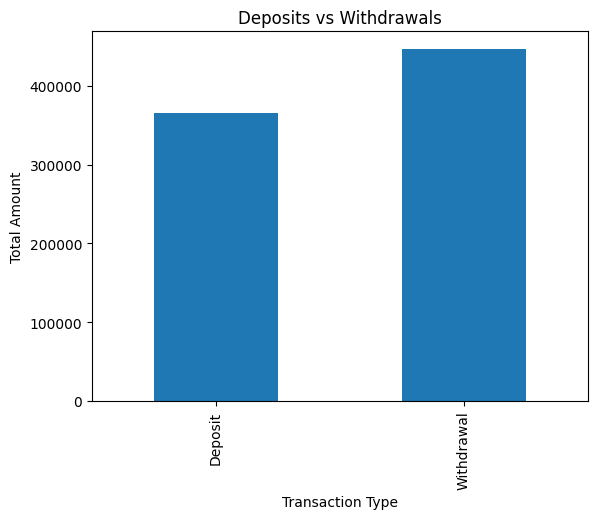

In [23]:
# Import Visualization Libraries

import matplotlib.pyplot as plt

# Deposits vs Withdrawals Chart

transaction_summary = df.groupby("TransactionType")["Amount"].sum()

transaction_summary.plot(kind="bar")

plt.title("Deposits vs Withdrawals")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount")
plt.show()

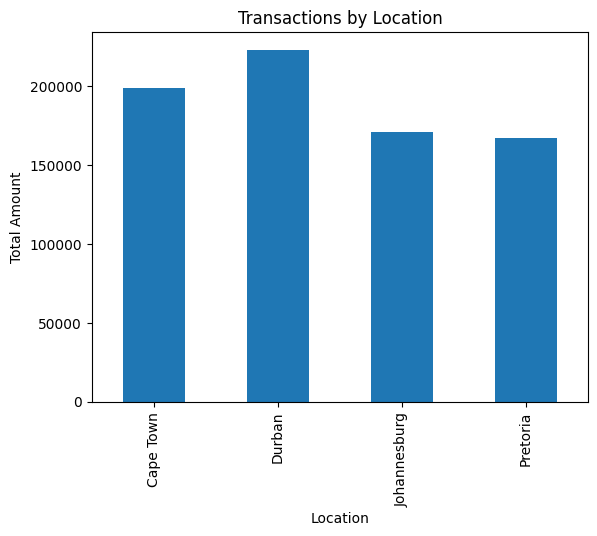

In [24]:
# Transactions by Location

location_summary = df.groupby("Location")["Amount"].sum()

location_summary.plot(kind="bar")

plt.title("Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Total Amount")
plt.show()

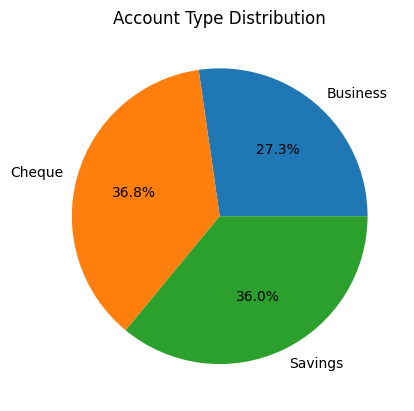

In [25]:
# Account Type Distribution

account_summary = df.groupby("AccountType")["Amount"].sum()

account_summary.plot(kind="pie", autopct='%1.1f%%')

plt.title("Account Type Distribution")
plt.ylabel("")
plt.show()

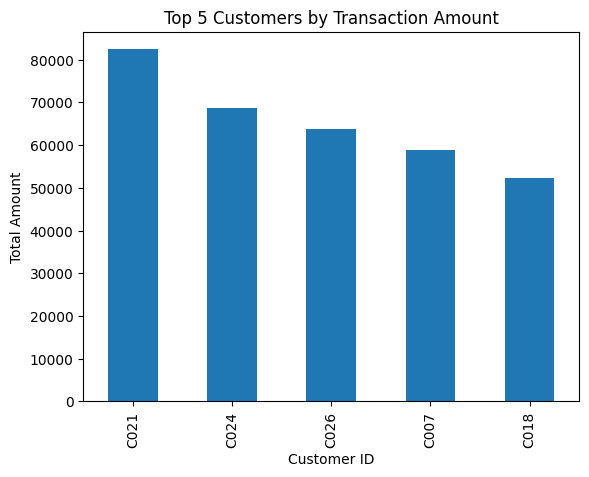

In [26]:
# Top Customers Chart

top_customers = df.groupby("CustomerID")["Amount"].sum().sort_values(ascending=False).head()

top_customers.plot(kind="bar")

plt.title("Top 5 Customers by Transaction Amount")
plt.xlabel("Customer ID")
plt.ylabel("Total Amount")
plt.show()

In [28]:
# Generate Business Insights Summary

insights = {
    "Total Transactions": len(df),
    "Total Deposits": df[df["TransactionType"] == "Deposit"]["Amount"].sum(),
    "Total Withdrawals": df[df["TransactionType"] == "Withdrawal"]["Amount"].sum(),
    "Highest Transaction": df["Amount"].max(),
    "Lowest Transaction": df["Amount"].min(),
    "Most Active Location": df["Location"].mode()[0],
    "Most Common Account Type": df["AccountType"].mode()[0]
}

insights_df = pd.DataFrame([insights])

insights_df

,Total Transactions,Total Deposits,Total Withdrawals,Highest Transaction,Lowest Transaction,Most Active Location,Most Common Account Type
0,105,364906.0,446804.0,35781.0,-4875.0,Durban,Cheque


## 7. Report Generation

In [29]:
# Export Insights Report

insights_df.to_csv("banking_insights_report.csv", index=False)